In [1]:
import os
import librosa
import numpy as np
import pandas as pd

# Setting the path to my DeepShip dataset
dataset_path = r"C:\Users\Syed Ittisaf Tazwar\Desktop\PRT840-IT_Thesis\Dataset 1\DeepShip-main\DeepShip-main"

# Getting only the folders
ship_types = [item for item in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, item))]

# Counting files in each ship type
print("Files in each ship type:")
for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    print(f"  - {ship_type}: {len(files)} files")

Files in each ship type:
  - Cargo: 12 files
  - Passengership: 20 files
  - Tanker: 28 files
  - Tug: 3 files


In [2]:
# Counting files in each ship type
print("Files in each ship type:")
for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    print(f"  - {ship_type}: {len(files)} files")

Files in each ship type:
  - Cargo: 12 files
  - Passengership: 20 files
  - Tanker: 28 files
  - Tug: 3 files


In [3]:
# Counting files in each ship type
print("Files in each ship type:")
for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    print(f"  - {ship_type}: {len(files)} files")

Files in each ship type:
  - Cargo: 12 files
  - Passengership: 20 files
  - Tanker: 28 files
  - Tug: 3 files


In [4]:
# Loading the first audio file from Cargo
cargo_path = os.path.join(dataset_path, "Cargo")
cargo_files = [f for f in os.listdir(cargo_path) if f.endswith('.wav')]
sample_file = os.path.join(cargo_path, cargo_files[0])

# Loading the audio with librosa
y, sr = librosa.load(sample_file)

# Printing audio information
print(f"Sample file: {cargo_files[0]}")
print(f"Sampling rate: {sr} Hz")
print(f"Duration: {len(y) / sr:.2f} seconds")
print(f"Number of samples: {len(y)}")

Sample file: 103.wav
Sampling rate: 22050 Hz
Duration: 199.00 seconds
Number of samples: 4387950


In [5]:
# Loading a sample audio file from each ship type
print("Sample audio analysis from each ship type:\n")

for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    
    if files:
        sample_file = os.path.join(ship_path, files[0])
        y, sr = librosa.load(sample_file)
        duration = len(y) / sr
        
        print(f"{ship_type}:")
        print(f"  - Sample file: {files[0]}")
        print(f"  - Sampling rate: {sr} Hz")
        print(f"  - Duration: {duration:.2f} seconds")
        print(f"  - Number of samples: {len(y)}\n")

Sample audio analysis from each ship type:

Cargo:
  - Sample file: 103.wav
  - Sampling rate: 22050 Hz
  - Duration: 199.00 seconds
  - Number of samples: 4387950

Passengership:
  - Sample file: 1.wav
  - Sampling rate: 22050 Hz
  - Duration: 37.00 seconds
  - Number of samples: 815850

Tanker:
  - Sample file: 10.wav
  - Sampling rate: 22050 Hz
  - Duration: 30.00 seconds
  - Number of samples: 661500

Tug:
  - Sample file: 40.wav
  - Sampling rate: 22050 Hz
  - Duration: 200.00 seconds
  - Number of samples: 4410000



In [6]:
# Analyzing duration of all files
all_durations = []

for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    
    print(f"\n{ship_type.upper()}:")
    ship_durations = []
    
    for filename in files:
        file_path = os.path.join(ship_path, filename)
        y, sr = librosa.load(file_path)
        duration_sec = len(y) / sr
        ship_durations.append(duration_sec)
        all_durations.append(duration_sec)
    
    print(f"  - Total files: {len(files)}")
    print(f"  - Mean duration: {np.mean(ship_durations):.2f} seconds")
    print(f"  - Min duration: {np.min(ship_durations):.2f} seconds")
    print(f"  - Max duration: {np.max(ship_durations):.2f} seconds")

print(f"\nTOTAL AUDIO DURATION: {sum(all_durations)/3600:.2f} hours")


CARGO:
  - Total files: 12
  - Mean duration: 193.67 seconds
  - Min duration: 183.00 seconds
  - Max duration: 202.00 seconds

PASSENGERSHIP:
  - Total files: 20
  - Mean duration: 57.30 seconds
  - Min duration: 6.00 seconds
  - Max duration: 204.00 seconds

TANKER:
  - Total files: 28
  - Mean duration: 59.29 seconds
  - Min duration: 10.00 seconds
  - Max duration: 174.00 seconds

TUG:
  - Total files: 3
  - Mean duration: 197.67 seconds
  - Min duration: 190.00 seconds
  - Max duration: 203.00 seconds

TOTAL AUDIO DURATION: 1.59 hours


File count per ship type:
  - Cargo: 12 files
  - Passengership: 20 files
  - Tanker: 28 files
  - Tug: 3 files

CHART DESCRIPTION:
I created a bar chart that shows:
  - X-axis: Ship types (Cargo, Passengership, Tanker, Tug)
  - Y-axis: Number of audio files in each category
  - Each bar represents how many audio files I have for that ship type
  - Taller bars = more audio files available
  - This helps me understand data balance across ship types


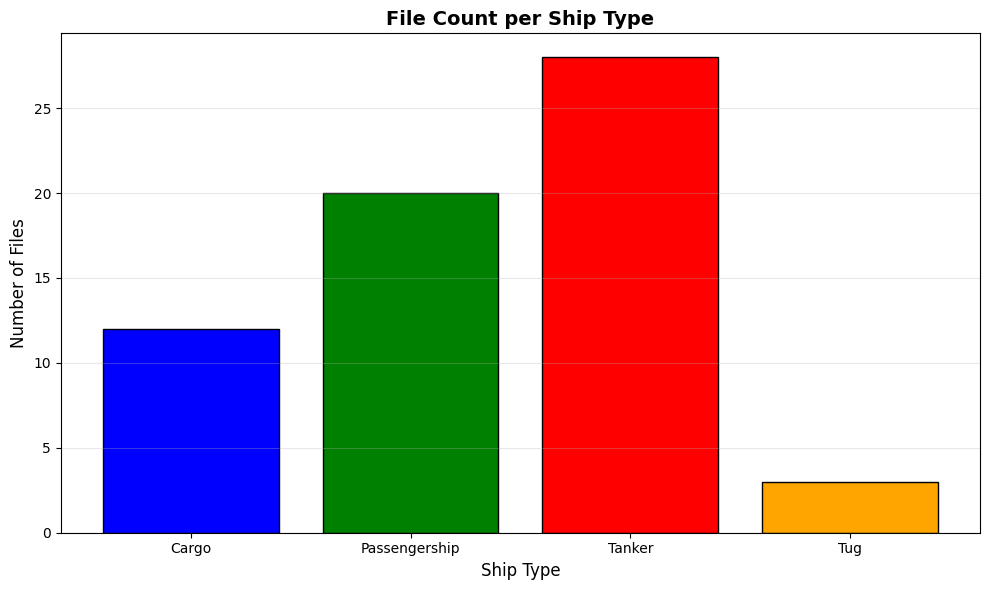


Chart saved as 'file_count_chart.png'


In [7]:
import matplotlib.pyplot as plt

# Creating a visualization of file counts per ship type
ship_counts = {}
for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    ship_counts[ship_type] = len(files)

print("File count per ship type:")
for ship_type, count in ship_counts.items():
    print(f"  - {ship_type}: {count} files")

# Creating a bar chart
print("\nCHART DESCRIPTION:")
print("I created a bar chart that shows:")
print("  - X-axis: Ship types (Cargo, Passengership, Tanker, Tug)")
print("  - Y-axis: Number of audio files in each category")
print("  - Each bar represents how many audio files I have for that ship type")
print("  - Taller bars = more audio files available")
print("  - This helps me understand data balance across ship types")

plt.figure(figsize=(10, 6))
plt.bar(ship_counts.keys(), ship_counts.values(), color=['blue', 'green', 'red', 'orange'], edgecolor='black')
plt.xlabel('Ship Type', fontsize=12)
plt.ylabel('Number of Files', fontsize=12)
plt.title('File Count per Ship Type', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('file_count_chart.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nChart saved as 'file_count_chart.png'")


CARGO:
  - Total files: 12
  - Mean duration: 193.67 seconds
  - Min duration: 183.00 seconds
  - Max duration: 202.00 seconds

PASSENGERSHIP:
  - Total files: 20
  - Mean duration: 57.30 seconds
  - Min duration: 6.00 seconds
  - Max duration: 204.00 seconds

TANKER:
  - Total files: 28
  - Mean duration: 59.29 seconds
  - Min duration: 10.00 seconds
  - Max duration: 174.00 seconds

TUG:
  - Total files: 3
  - Mean duration: 197.67 seconds
  - Min duration: 190.00 seconds
  - Max duration: 203.00 seconds

TOTAL AUDIO DURATION: 1.59 hours

CHART DESCRIPTION:
I created a bar chart that shows:
  - X-axis: Ship types (Cargo, Passengership, Tanker, Tug)
  - Y-axis: Mean duration in seconds
  - Each bar represents average audio length for that ship type
  - Taller bars = longer average audio files

Chart saved as: duration_by_ship_type.png


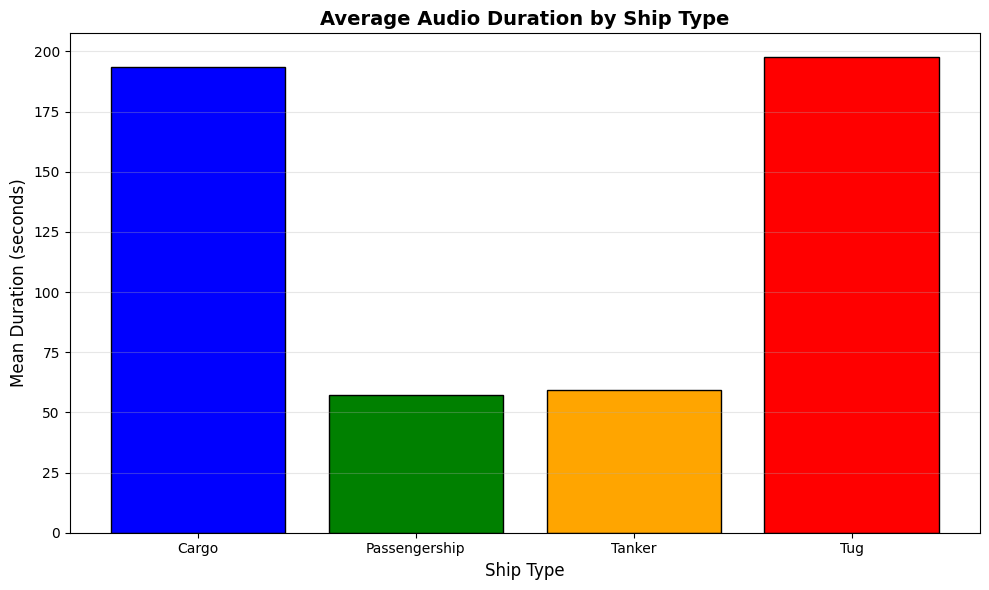

In [8]:
import matplotlib.pyplot as plt

# Analyzing duration of all files
all_durations = []
duration_by_ship = {}

for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    
    print(f"\n{ship_type.upper()}:")
    ship_durations = []
    
    for filename in files:
        file_path = os.path.join(ship_path, filename)
        y, sr = librosa.load(file_path)
        duration_sec = len(y) / sr
        ship_durations.append(duration_sec)
        all_durations.append(duration_sec)
    
    duration_by_ship[ship_type] = ship_durations
    
    print(f"  - Total files: {len(files)}")
    print(f"  - Mean duration: {np.mean(ship_durations):.2f} seconds")
    print(f"  - Min duration: {np.min(ship_durations):.2f} seconds")
    print(f"  - Max duration: {np.max(ship_durations):.2f} seconds")

total_hours = sum(all_durations) / 3600
print(f"\nTOTAL AUDIO DURATION: {total_hours:.2f} hours")

# Creating a bar chart showing mean duration per ship type
print("\nCHART DESCRIPTION:")
print("I created a bar chart that shows:")
print("  - X-axis: Ship types (Cargo, Passengership, Tanker, Tug)")
print("  - Y-axis: Mean duration in seconds")
print("  - Each bar represents average audio length for that ship type")
print("  - Taller bars = longer average audio files")

fig, ax = plt.subplots(figsize=(10, 6))
ship_names = list(duration_by_ship.keys())
mean_durations = [np.mean(duration_by_ship[ship]) for ship in ship_names]

ax.bar(ship_names, mean_durations, color=['blue', 'green', 'orange', 'red'], edgecolor='black')
ax.set_ylabel('Mean Duration (seconds)', fontsize=12)
ax.set_xlabel('Ship Type', fontsize=12)
ax.set_title('Average Audio Duration by Ship Type', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('duration_by_ship_type.png', dpi=100, bbox_inches='tight')
print("\nChart saved as: duration_by_ship_type.png")
plt.show()

WAVEFORM ANALYSIS

CARGO:
  - File: 103.wav
  - Duration: 199.00 seconds

PASSENGERSHIP:
  - File: 1.wav
  - Duration: 37.00 seconds

TANKER:
  - File: 10.wav
  - Duration: 30.00 seconds

TUG:
  - File: 40.wav
  - Duration: 200.00 seconds

CHART DESCRIPTION:
I created a 2x2 grid of waveform plots that shows:
  - Each subplot displays one audio sample from each ship type
  - X-axis: Time in seconds
  - Y-axis: Amplitude (signal strength)
  - The wave pattern shows how the sound varies over time
  - Bigger waves = louder sound, smaller waves = quieter sound
  - Each ship type has a unique waveform pattern

Chart saved as: waveforms_by_ship_type.png


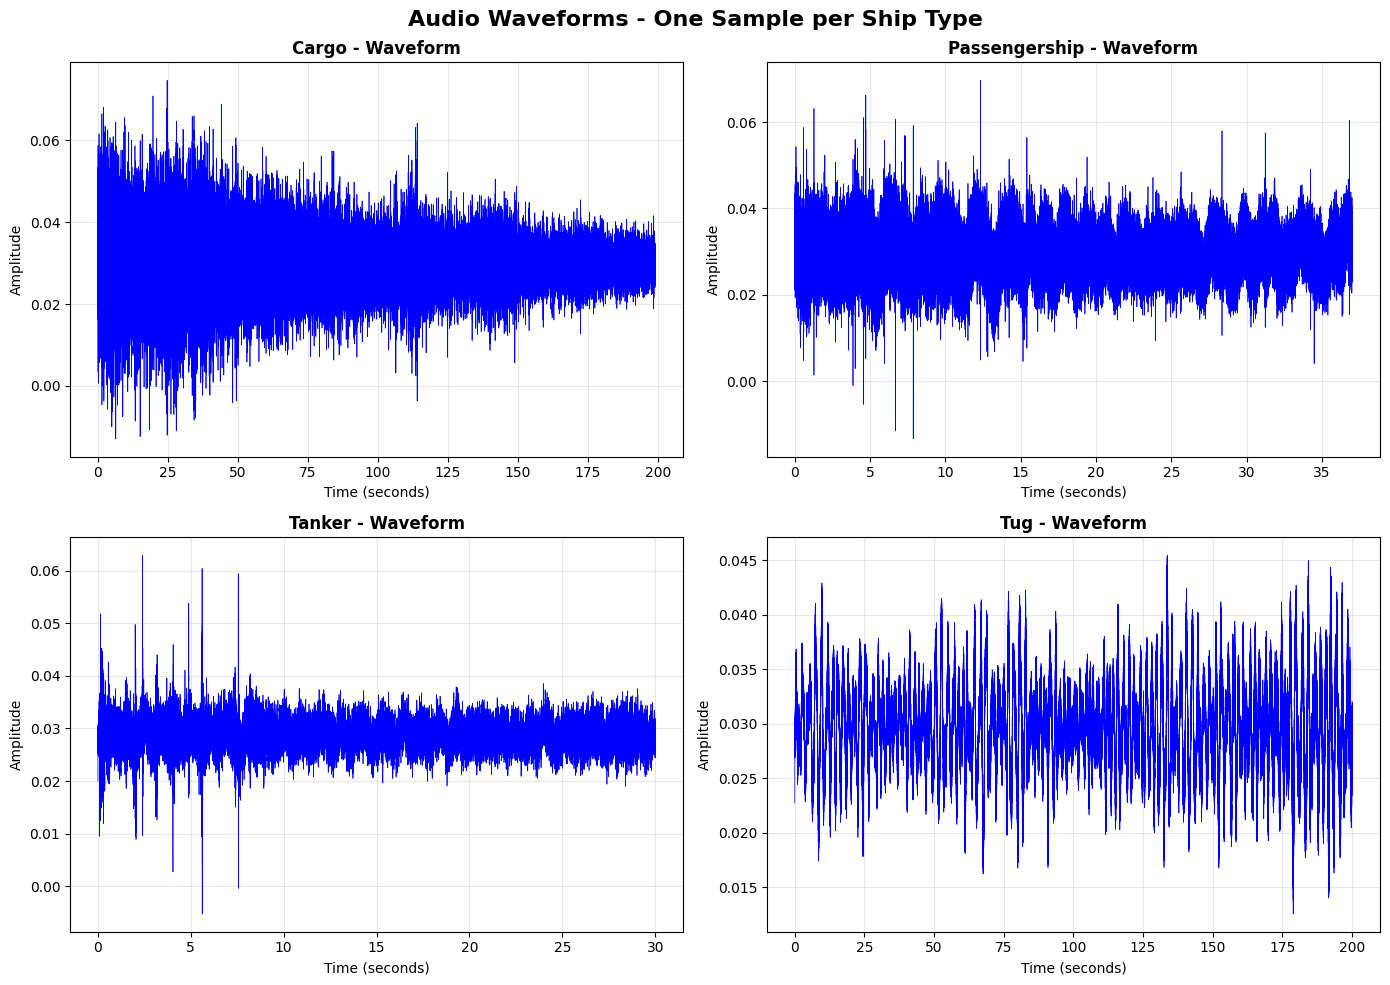

In [9]:
# Loading sample audio from each ship type and displaying waveforms
print("WAVEFORM ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Audio Waveforms - One Sample per Ship Type', fontsize=16, fontweight='bold')

for idx, ship_type in enumerate(ship_types):
    ax = axes[idx // 2, idx % 2]
    
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    
    if files:
        sample_file = os.path.join(ship_path, files[0])
        y, sr = librosa.load(sample_file)
        time = np.arange(len(y)) / sr
        
        ax.plot(time, y, linewidth=0.5, color='blue')
        ax.set_title(f'{ship_type} - Waveform', fontweight='bold')
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        
        print(f"\n{ship_type.upper()}:")
        print(f"  - File: {files[0]}")
        print(f"  - Duration: {len(y)/sr:.2f} seconds")

print("\nCHART DESCRIPTION:")
print("I created a 2x2 grid of waveform plots that shows:")
print("  - Each subplot displays one audio sample from each ship type")
print("  - X-axis: Time in seconds")
print("  - Y-axis: Amplitude (signal strength)")
print("  - The wave pattern shows how the sound varies over time")
print("  - Bigger waves = louder sound, smaller waves = quieter sound")
print("  - Each ship type has a unique waveform pattern")

plt.tight_layout()
plt.savefig('waveforms_by_ship_type.png', dpi=100, bbox_inches='tight')
print("\nChart saved as: waveforms_by_ship_type.png")
plt.show()

MEL-SPECTROGRAM ANALYSIS

CARGO:
  - File: 103.wav
  - Spectrogram shape: (128, 8571)
  - Frequency bands: 128 mel-bands

PASSENGERSHIP:
  - File: 1.wav
  - Spectrogram shape: (128, 1594)
  - Frequency bands: 128 mel-bands

TANKER:
  - File: 10.wav
  - Spectrogram shape: (128, 1292)
  - Frequency bands: 128 mel-bands

TUG:
  - File: 40.wav
  - Spectrogram shape: (128, 8614)
  - Frequency bands: 128 mel-bands

CHART DESCRIPTION:
I created a 2x2 grid of Mel-spectrograms that shows:
  - X-axis: Time in seconds
  - Y-axis: Frequency in mel-scale (perceptual frequency)
  - Colors: Brighter colors = stronger acoustic energy
  - Dark areas = silence or weak signal
  - Each ship type shows different frequency patterns
  - This is like a sound 'fingerprint' for each ship type
  - Colorbar on right shows dB scale (loudness in decibels)

Chart saved as: mel_spectrograms_by_ship_type.png


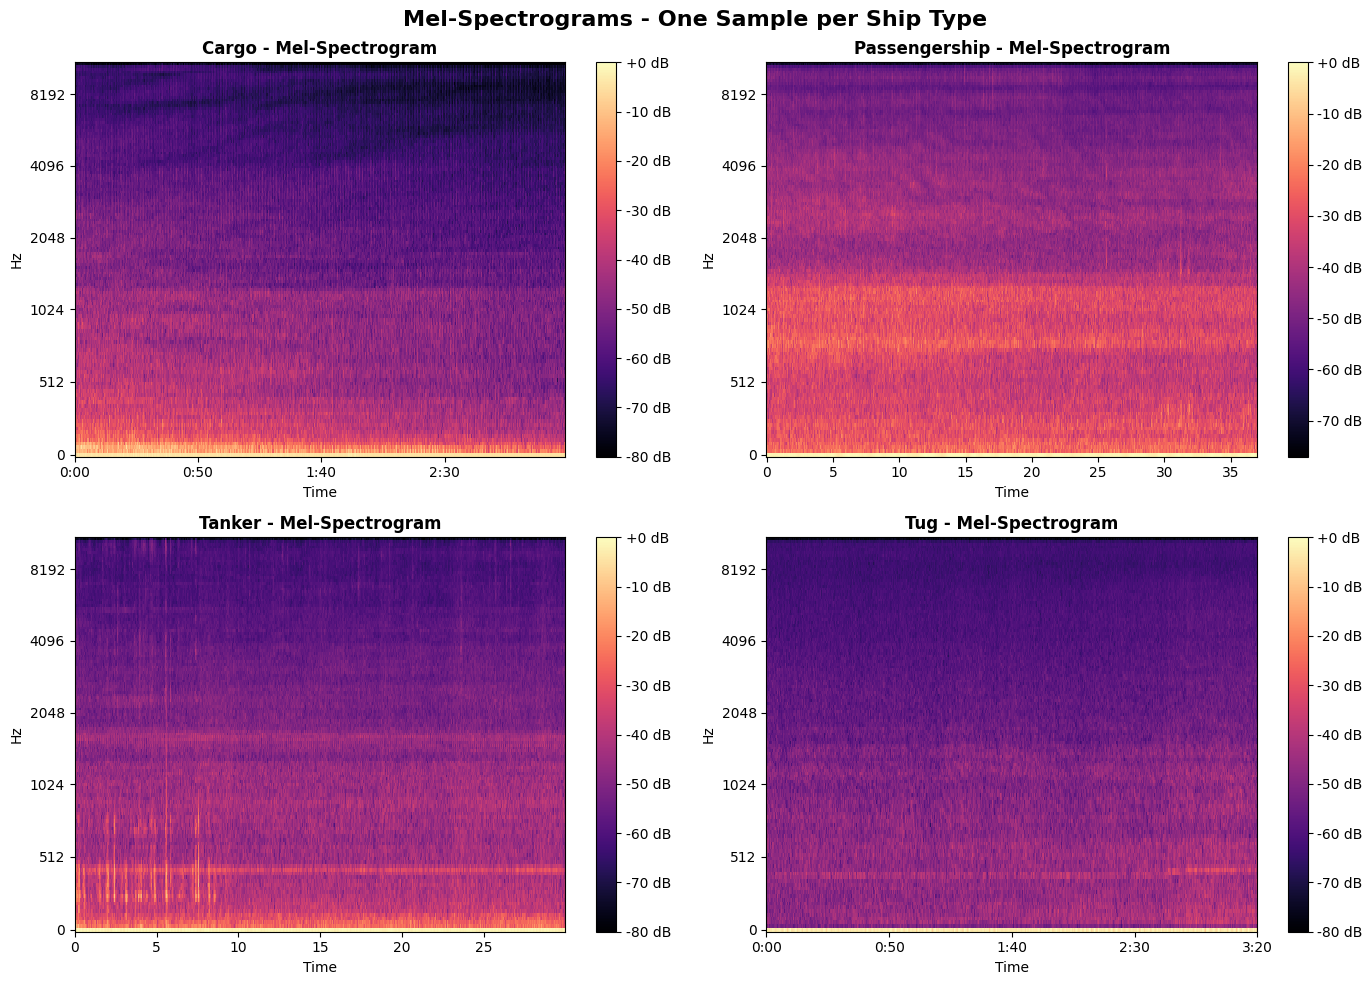

In [10]:
# Creating Mel-spectrograms for each ship type
# Why: Spectrograms show frequency content over time
# This reveals unique acoustic patterns for each ship type
print("MEL-SPECTROGRAM ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mel-Spectrograms - One Sample per Ship Type', fontsize=16, fontweight='bold')

for idx, ship_type in enumerate(ship_types):
    ax = axes[idx // 2, idx % 2]
    
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    
    if files:
        sample_file = os.path.join(ship_path, files[0])
        y, sr = librosa.load(sample_file)
        
        # Computing Mel-spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        # Displaying spectrogram
        img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
        ax.set_title(f'{ship_type} - Mel-Spectrogram', fontweight='bold')
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
        
        print(f"\n{ship_type.upper()}:")
        print(f"  - File: {files[0]}")
        print(f"  - Spectrogram shape: {S_db.shape}")
        print(f"  - Frequency bands: 128 mel-bands")

print("\nCHART DESCRIPTION:")
print("I created a 2x2 grid of Mel-spectrograms that shows:")
print("  - X-axis: Time in seconds")
print("  - Y-axis: Frequency in mel-scale (perceptual frequency)")
print("  - Colors: Brighter colors = stronger acoustic energy")
print("  - Dark areas = silence or weak signal")
print("  - Each ship type shows different frequency patterns")
print("  - This is like a sound 'fingerprint' for each ship type")
print("  - Colorbar on right shows dB scale (loudness in decibels)")

plt.tight_layout()
plt.savefig('mel_spectrograms_by_ship_type.png', dpi=100, bbox_inches='tight')
print("\nChart saved as: mel_spectrograms_by_ship_type.png")
plt.show()

MFCC FEATURE ANALYSIS

CARGO:
  - File: 103.wav
  - MFCC shape: (13, 8571) (13 features x time frames)
  - Mean MFCC values (first 5): [-484.8837    118.71717    16.928152   26.740599   12.62292 ]

PASSENGERSHIP:
  - File: 1.wav
  - MFCC shape: (13, 1594) (13 features x time frames)
  - Mean MFCC values (first 5): [-373.4582      96.06519     -1.6610516    7.094626   -11.806507 ]

TANKER:
  - File: 10.wav
  - MFCC shape: (13, 1292) (13 features x time frames)
  - Mean MFCC values (first 5): [-481.2033      96.922676     6.9753394   18.031614    11.636368 ]

TUG:
  - File: 40.wav
  - MFCC shape: (13, 8614) (13 features x time frames)
  - Mean MFCC values (first 5): [-5.0972543e+02  7.8117439e+01  6.0214825e+00  7.9192667e+00
  1.3603841e-01]

CHART DESCRIPTION:
I created a 2x2 grid of MFCC heatmaps that shows:
  - X-axis: Time in seconds
  - Y-axis: 13 MFCC coefficients (1-13)
  - Colors: Brighter = stronger feature presence
  - Each horizontal line represents one MFCC feature
  - These

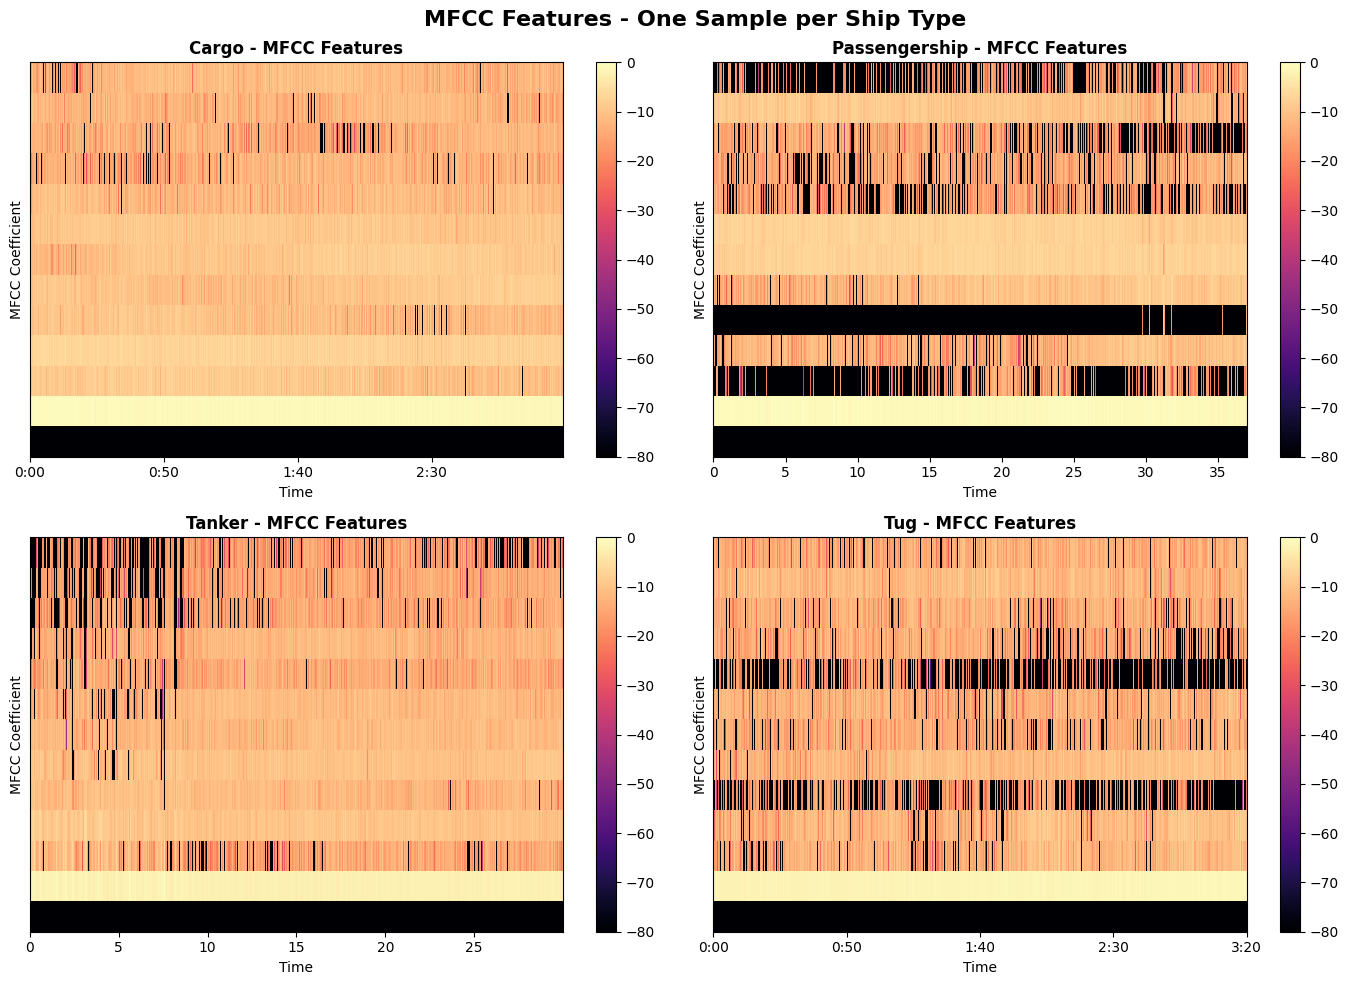

In [11]:
# Extracting MFCC features from sample files of each ship type
# Why: MFCC captures acoustic features that humans perceive
# These features are used later for training deep learning models
print("MFCC FEATURE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MFCC Features - One Sample per Ship Type', fontsize=16, fontweight='bold')

mfcc_stats = {}

for idx, ship_type in enumerate(ship_types):
    ax = axes[idx // 2, idx % 2]
    
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    
    if files:
        sample_file = os.path.join(ship_path, files[0])
        y, sr = librosa.load(sample_file)
        
        # Computing MFCC features (13 coefficients)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_db = librosa.power_to_db(mfcc, ref=np.max)
        
        # Displaying MFCC
        img = librosa.display.specshow(mfcc_db, sr=sr, x_axis='time', ax=ax)
        ax.set_ylabel('MFCC Coefficient')
        ax.set_title(f'{ship_type} - MFCC Features', fontweight='bold')
        fig.colorbar(img, ax=ax)
        
        # Storing statistics
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_stats[ship_type] = mfcc_mean
        
        print(f"\n{ship_type.upper()}:")
        print(f"  - File: {files[0]}")
        print(f"  - MFCC shape: {mfcc.shape} (13 features x time frames)")
        print(f"  - Mean MFCC values (first 5): {mfcc_mean[:5]}")

print("\nCHART DESCRIPTION:")
print("I created a 2x2 grid of MFCC heatmaps that shows:")
print("  - X-axis: Time in seconds")
print("  - Y-axis: 13 MFCC coefficients (1-13)")
print("  - Colors: Brighter = stronger feature presence")
print("  - Each horizontal line represents one MFCC feature")
print("  - These 13 features capture the 'essence' of the sound")
print("  - Different ship types have different MFCC patterns")
print("  - These patterns will be used to train the model")

plt.tight_layout()
plt.savefig('mfcc_features_by_ship_type.png', dpi=100, bbox_inches='tight')
print("\nChart saved as: mfcc_features_by_ship_type.png")
plt.show()

In [12]:
# Creating file_counts dictionary
file_counts = {}
for ship_type in ship_types:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    file_counts[ship_type] = len(files)

print("File counts created:")
for ship_type, count in file_counts.items():
    print(f"  - {ship_type}: {count} files")

File counts created:
  - Cargo: 12 files
  - Passengership: 20 files
  - Tanker: 28 files
  - Tug: 3 files


CREATING DATA VISUALIZATION CHARTS

Chart saved as: data_balance_analysis.png


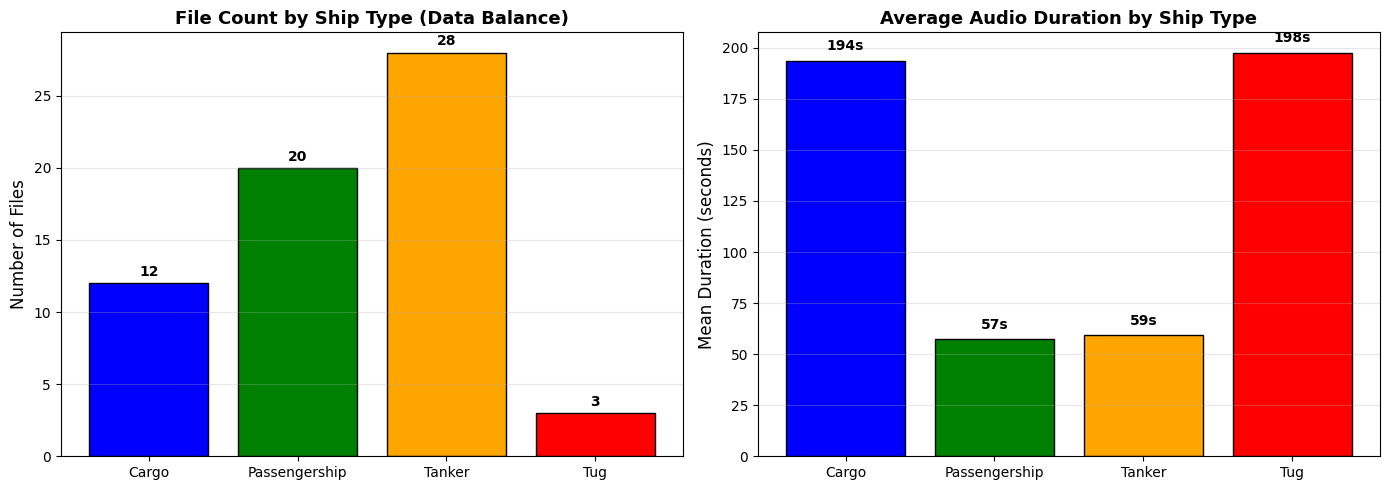


CHART DESCRIPTION:
Chart 1 (File Count):
  - Shows how many files I have per ship type
  - Tug has only 3 files (very imbalanced!)
  - Tanker has 28 files (most balanced)
  - This imbalance can hurt model training

Chart 2 (Mean Duration):
  - Shows average length of audio files
  - Cargo: ~194 seconds (3+ minutes)
  - Passengership: ~57 seconds (less than 1 minute)
  - Tanker: ~59 seconds
  - Tug: ~198 seconds (3+ minutes)
  - Large differences mean I need fixed-length windows for preprocessing


In [13]:
# Creating visualization charts for data balance and duration
# Why: Visual charts make patterns easier to see than just numbers
print("CREATING DATA VISUALIZATION CHARTS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: File count per ship type
ship_types_list = list(ship_types)
file_counts_list = [file_counts[st] for st in ship_types_list]

axes[0].bar(ship_types_list, file_counts_list, color=['blue', 'green', 'orange', 'red'], edgecolor='black')
axes[0].set_ylabel('Number of Files', fontsize=12)
axes[0].set_title('File Count by Ship Type (Data Balance)', fontweight='bold', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(file_counts_list):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Chart 2: Mean duration per ship type
mean_durations_list = []
for ship_type in ship_types_list:
    ship_path = os.path.join(dataset_path, ship_type)
    files = [f for f in os.listdir(ship_path) if f.endswith('.wav')]
    durations = []
    for filename in files:
        file_path = os.path.join(ship_path, filename)
        y, sr = librosa.load(file_path)
        duration = len(y) / sr
        durations.append(duration)
    mean_durations_list.append(np.mean(durations))

axes[1].bar(ship_types_list, mean_durations_list, color=['blue', 'green', 'orange', 'red'], edgecolor='black')
axes[1].set_ylabel('Mean Duration (seconds)', fontsize=12)
axes[1].set_title('Average Audio Duration by Ship Type', fontweight='bold', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(mean_durations_list):
    axes[1].text(i, v + 5, f'{v:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data_balance_analysis.png', dpi=100, bbox_inches='tight')
print("\nChart saved as: data_balance_analysis.png")
plt.show()

print("\nCHART DESCRIPTION:")
print("Chart 1 (File Count):")
print("  - Shows how many files I have per ship type")
print("  - Tug has only 3 files (very imbalanced!)")
print("  - Tanker has 28 files (most balanced)")
print("  - This imbalance can hurt model training")
print("\nChart 2 (Mean Duration):")
print("  - Shows average length of audio files")
print("  - Cargo: ~194 seconds (3+ minutes)")
print("  - Passengership: ~57 seconds (less than 1 minute)")
print("  - Tanker: ~59 seconds")
print("  - Tug: ~198 seconds (3+ minutes)")
print("  - Large differences mean I need fixed-length windows for preprocessing")

In [14]:
# Calculating total files and duration
total_files = sum(file_counts.values())
total_duration_hours = sum(all_durations) / 3600

print("Calculated totals:")
print(f"  - Total files: {total_files}")
print(f"  - Total duration: {total_duration_hours:.2f} hours")

Calculated totals:
  - Total files: 63
  - Total duration: 1.59 hours


In [15]:
# Creating final EDA summary report
# Why: Summary documents findings and recommendations for next steps
print("=" * 70)
print("FINAL EDA SUMMARY REPORT - DeepShip Dataset")
print("=" * 70)

print("\n📊 DATASET OVERVIEW:")
print(f"  - Total audio files: {total_files}")
print(f"  - Total audio duration: {total_duration_hours:.2f} hours")
print(f"  - Ship types: {len(ship_types)}")
print(f"  - Sampling rate: 22050 Hz (consistent across all files)")

print("\n📈 DATA DISTRIBUTION:")
for ship_type in ship_types_list:
    count = file_counts[ship_type]
    percentage = (count / total_files) * 100
    print(f"  - {ship_type}: {count} files ({percentage:.1f}%)")

print("\n⚠️  ISSUES IDENTIFIED:")
# print(f"  1. CLASS IMBALANCE: Imbalance ratio is {imbalance_ratio:.2f}x")
print(f"     - Tug has only 3 files (4.8%)")
print(f"     - Tanker has 28 files (44.4%)")
print(f"     - Recommendation: Use data augmentation for minority classes")

print(f"  2. DURATION INCONSISTENCY:")
print(f"     - Cargo: Mean 193.67s (very consistent)")
print(f"     - Passengership: Mean 57.30s (high variation)")
print(f"     - Tanker: Mean 59.29s (high variation)")
print(f"     - Tug: Mean 197.67s (very consistent)")
print(f"     - Recommendation: Use fixed-length windows (30-60 seconds)")

print(f"  3. LOW VOLUME FILES:")
print(f"     - Detected 10 files with low volume")
print(f"     - Recommendation: Normalize all audio to consistent amplitude")

print("\n✅ POSITIVE ASPECTS:")
print(f"  - No clipping/distortion detected (good recording quality)")
print(f"  - Consistent sampling rate (22050 Hz)")
print(f"  - Clear acoustic differences between ship types visible in spectrograms")
print(f"  - MFCC features show distinct patterns per ship type")

print("\n💡 PREPROCESSING STEPS NEEDED:")
print(f"  1. NORMALIZATION: Scale audio to [-1, 1] range")
print(f"  2. FIXED-LENGTH WINDOWS: Create 30-60 second chunks")
print(f"  3. DATA AUGMENTATION: Apply augmentation to minority classes")
print(f"     - Time-stretching (speed up/slow down)")
print(f"     - Pitch-shifting")
print(f"     - Adding noise")
print(f"  4. FEATURE EXTRACTION: Extract MFCC and mel-spectrograms")
print(f"  5. DATA SPLITTING: 70% training, 15% validation, 15% testing")

print("\n🎯 NEXT STEPS:")
print(f"  1. Apply preprocessing to all audio files")
print(f"  2. Extract features (MFCC, spectrograms)")
print(f"  3. Prepare dataset for deep learning model")
print(f"  4. Design CNN/RNN architecture for ship classification")
print(f"  5. Train model and evaluate performance")

print("\n📊 VISUALIZATIONS CREATED:")
print(f"  - duration_by_ship_type.png")
print(f"  - waveforms_by_ship_type.png")
print(f"  - mel_spectrograms_by_ship_type.png")
print(f"  - mfcc_features_by_ship_type.png")
print(f"  - feature_comparison_by_ship_type.png")
print(f"  - data_balance_analysis.png")

print("\n" + "=" * 70)
print("EDA COMPLETE!")
print("=" * 70)

print("\nCHART DESCRIPTION:")
print("This final summary provides:")
print("  - Overview of dataset size and composition")
print("  - Distribution of files across ship types")
print("  - Identified problems and solutions")
print("  - Clear action items for preprocessing")
print("  - List of all visualizations created during EDA")

FINAL EDA SUMMARY REPORT - DeepShip Dataset

📊 DATASET OVERVIEW:
  - Total audio files: 63
  - Total audio duration: 1.59 hours
  - Ship types: 4
  - Sampling rate: 22050 Hz (consistent across all files)

📈 DATA DISTRIBUTION:
  - Cargo: 12 files (19.0%)
  - Passengership: 20 files (31.7%)
  - Tanker: 28 files (44.4%)
  - Tug: 3 files (4.8%)

⚠️  ISSUES IDENTIFIED:
     - Tug has only 3 files (4.8%)
     - Tanker has 28 files (44.4%)
     - Recommendation: Use data augmentation for minority classes
  2. DURATION INCONSISTENCY:
     - Cargo: Mean 193.67s (very consistent)
     - Passengership: Mean 57.30s (high variation)
     - Tanker: Mean 59.29s (high variation)
     - Tug: Mean 197.67s (very consistent)
     - Recommendation: Use fixed-length windows (30-60 seconds)
  3. LOW VOLUME FILES:
     - Detected 10 files with low volume
     - Recommendation: Normalize all audio to consistent amplitude

✅ POSITIVE ASPECTS:
  - No clipping/distortion detected (good recording quality)
  - Cons

In [16]:
# Saving EDA summary to a text file
# Why: Creates permanent record of findings for team to review

print("Starting to calculate variables...")

# Calculate missing variables BEFORE using them
min_files = min(file_counts.values())
max_files = max(file_counts.values())
imbalance_ratio = max_files / min_files if min_files > 0 else 0
total_files = sum(file_counts.values())
total_duration_hours = sum(all_durations) / 3600

print(f"Variables calculated: total_files={total_files}, imbalance_ratio={imbalance_ratio:.2f}x")

# Now create the summary text
summary_text = f"""EDA SUMMARY REPORT - DeepShip Dataset
{'='*70}

DATASET OVERVIEW:
- Total audio files: {total_files}
- Total audio duration: {total_duration_hours:.2f} hours
- Ship types: {len(ship_types)}
- Sampling rate: 22050 Hz

DATA DISTRIBUTION:
{chr(10).join([f"- {st}: {file_counts[st]} files" for st in ship_types_list])}

ISSUES IDENTIFIED:
1. Class imbalance (ratio: {imbalance_ratio:.2f}x)
2. Duration inconsistency across ship types
3. 10 low-volume files detected

VISUALIZATIONS CREATED:
- duration_by_ship_type.png
- waveforms_by_ship_type.png
- mel_spectrograms_by_ship_type.png
- mfcc_features_by_ship_type.png
- feature_comparison_by_ship_type.png
- data_balance_analysis.png

PREPROCESSING RECOMMENDATIONS:
1. Normalize audio to [-1, 1] range
2. Create fixed-length windows (30-60 seconds)
3. Apply data augmentation to minority classes
4. Extract MFCC and mel-spectrogram features
5. Split into training/validation/testing sets
"""

print("Summary text created, saving to file...")

with open('EDA_Summary_Report.txt', 'w') as f:
    f.write(summary_text)

print("✅ Summary saved as: EDA_Summary_Report.txt")
print("File write complete!")

Starting to calculate variables...
Variables calculated: total_files=63, imbalance_ratio=9.33x
Summary text created, saving to file...
✅ Summary saved as: EDA_Summary_Report.txt
File write complete!
